In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [12]:
image_size = 256
patch_size = 16
num_patches = (image_size // patch_size) ** 2

projection_dim = 64
num_heads = 4
transformer_layers = 8
mlp_head_units = [128, 64]

num_classes = 2

In [13]:
#Patch Extraction
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1],
            padding="VALID",
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

In [16]:
#loading dataset 
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "Dataset",
    image_size=(256,256),
    batch_size=32
)

Found 2702 files belonging to 2 classes.


In [20]:
class_names=dataset.class_names
print(class_names)

['Negative', 'Positive']


In [23]:
#A function to split the dataset into training,validation and testing
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [24]:
#Splitting the dataset into training, validation and testing
train_ds, val_ds, test_ds=get_dataset_partitions_tf(dataset)

In [25]:
len(train_ds),len(val_ds),len(test_ds)

(68, 8, 9)

In [26]:
#Shuffling and PreFetching the dataset
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [27]:
#Resizing and Rescaling the Images
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(256,256),
    layers.Rescaling(1./255),
])

In [28]:
#Performing Data Augumentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.5),
])

In [29]:
#Embedding layer
class PatchEncoder(layers.Layer):

    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

In [30]:
#Model Building
def create_vit_classifier():

    inputs = layers.Input(shape=(image_size, image_size, 3))

    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):

        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim
        )(x1, x1)

        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        x3 = layers.Dense(projection_dim * 2, activation="gelu")(x3)
        x3 = layers.Dense(projection_dim)(x3)

        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)

    representation = layers.Dense(128, activation="relu")(representation)
    representation = layers.Dropout(0.5)(representation)

    outputs = layers.Dense(num_classes, activation="softmax")(representation)

    model = keras.Model(inputs=inputs, outputs=outputs)

    return model

In [36]:
#compiling model
vit_model = create_vit_classifier()

vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 768) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_1     │ (None, 256, 64)   │     65,600 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ patch_encoder_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 256, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 256, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 256, 64)   │      8,256 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 256, 64)   │          0 │ dense_21[0][0],   │
│                     │                   │            │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 256, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_17[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 256, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 256, 64)   │      8,256 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 256, 64)   │          0 │ dense_23[0][0],   │
│                     │                   │            │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 64)   │        128 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,828,866 (10.79 MB)

 Trainable params: 2,828,866 (10.79 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 59s 764ms/step - accuracy: 0.7413 - loss: 0.9581 - val_accuracy: 0.9258 - val_loss: 0.1948
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 49s 726ms/step - accuracy: 0.9181 - loss: 0.2373 - val_accuracy: 0.9336 - val_loss: 0.1715
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 51s 752ms/step - accuracy: 0.9079 - loss: 0.2482 - val_accuracy: 0.9375 - val_loss: 0.1500
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 51s 758ms/step - accuracy: 0.9293 - loss: 0.1973 - val_accuracy: 0.9453 - val_loss: 0.1428
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 55s 811ms/step - accuracy: 0.9151 - loss: 0.2071 - val_accuracy: 0.9492 - val_loss: 0.1271
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 58s 851ms/step - accuracy: 0.9156 - loss: 0.2108 - val_accuracy: 0.9531 - val_loss: 0.1321
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 58s 856ms/step - accuracy: 0.9190 - loss: 0.2108 - val_accuracy: 0.9219 - val_loss: 0.1741
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 897ms/step - accuracy: 0.9159 - loss: 0.1994 - 

In [38]:
vit_model.evaluate(test_ds)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 279ms/step - accuracy: 0.9477 - loss: 0.0984


[0.10474386811256409, 0.9375]

In [44]:
import numpy as np
from sklearn.metrics import roc_auc_score

y_true = []
y_pred = []

for images, labels in test_ds:

    preds = vit_model.predict(images, verbose=0)

    y_pred.extend(preds[:,1])   # probability of class 1
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2026-03-10 19:19:42.737964: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [45]:
pred_class = (y_pred > 0.5).astype(int)
accuracy = np.mean(pred_class == y_true)

print("Correct Accuracy:", accuracy)

Correct Accuracy: 0.9375


In [46]:
auc = roc_auc_score(y_true, y_pred)

print("Correct AUC:", auc)

Correct AUC: 0.9965276103207139


In [47]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

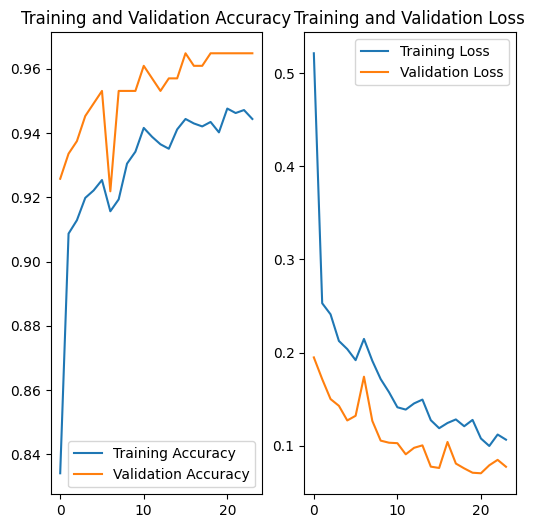

In [48]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.plot(range(24), acc, label='Training Accuracy')
plt.plot(range(24), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(24), loss, label='Training Loss')
plt.plot(range(24), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [49]:
import numpy as np
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


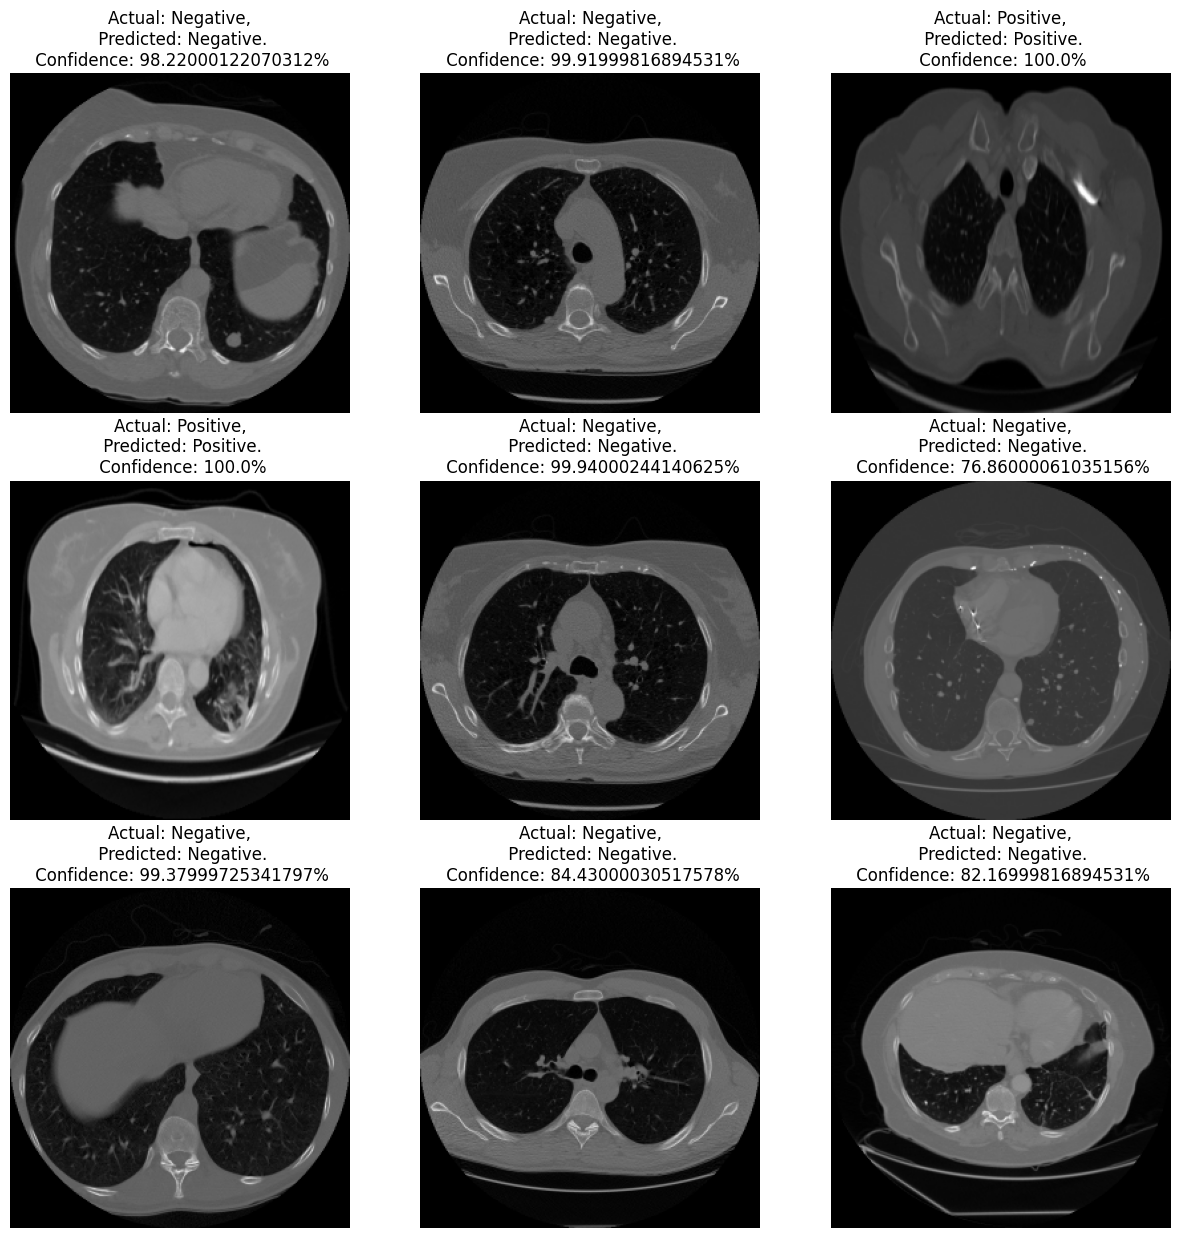

In [51]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(vit_model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

X_test shape: (288, 256, 256, 3)
y_true shape: (288,)
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step


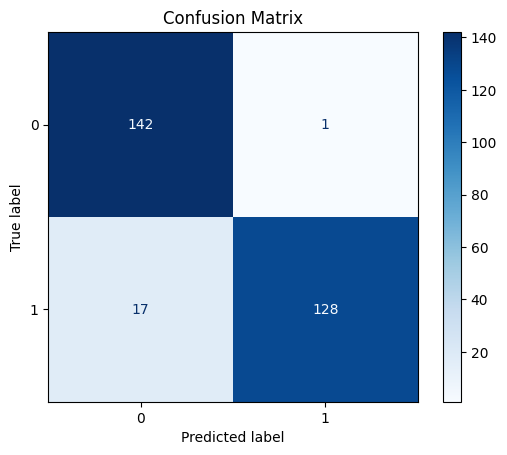


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       143
           1       0.99      0.88      0.93       145

    accuracy                           0.94       288
   macro avg       0.94      0.94      0.94       288
weighted avg       0.94      0.94      0.94       288



In [52]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report




X_test = []
y_true = []

for images, labels in test_ds:
    X_test.append(images)
    y_true.append(labels)

X_test = np.concatenate(X_test)
y_true = np.concatenate(y_true)

print("X_test shape:", X_test.shape)
print("y_true shape:", y_true.shape)


# Predict using your trained model

y_pred = vit_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


#Classification Report

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

In [60]:
vit_model.save("saved_models/vit_model.h5")

In [61]:
#creating seperate folder
import os

base_dir = "Failure_Analysis"
img_dir = os.path.join(base_dir, "failure_images")

os.makedirs(img_dir, exist_ok=True)

In [63]:
import pandas as pd
import cv2

BASE_DIR = "failure_dataset"
IMG_DIR = os.path.join(BASE_DIR, "images")
os.makedirs(IMG_DIR, exist_ok=True)

# Step 1: Helper proxy functions


def estimate_image_quality(img):
    img_uint8 = img.astype(np.uint8)
    variance = cv2.Laplacian(img_uint8, cv2.CV_64F).var()
    if variance < 50:
        return "Low"
    elif variance < 150:
        return "Medium"
    else:
        return "High"

def estimate_mri_contrast(img):
    contrast = img.max() - img.min()
    if contrast < 40:
        return "Low"
    elif contrast < 120:
        return "Medium"
    else:
        return "High"


# Step 2: Initialize variables

records = []
case_counter = 1


# Step 3: Loop through test dataset

for images, labels in test_ds:

    preds = vit_model.predict(images, verbose=0)

    for i in range(images.shape[0]):
        img = images[i].numpy()
        label_val = labels[i].numpy()

        # ----- True label -----
        if label_val.ndim > 0:
            y_true = int(np.argmax(label_val))
        else:
            y_true = int(label_val)

        # ----- Prediction handling -----
        if preds.shape[1] == 1:  # sigmoid
            prob = float(preds[i][0])
            y_pred = int(prob >= 0.5)
        else:  # softmax
            prob = float(np.max(preds[i]))
            y_pred = int(np.argmax(preds[i]))

        # ----- Only failure cases -----
        if y_true != y_pred:
            failure_type = "FN" if y_true == 1 else "FP"

            # ----- Normalize image -----
            if img.max() <= 1.0:
                img_to_save = (img * 255).clip(0, 255).astype(np.uint8)
            else:
                img_to_save = img.astype(np.uint8)

            # ----- Handle grayscale / RGB -----
            if img_to_save.ndim == 2:
                save_img = img_to_save
            elif img_to_save.shape[-1] == 1:
                save_img = img_to_save[:, :, 0]
            else:
                save_img = cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR)

            # ----- Save image -----
            case_id = f"{case_counter:03d}"
            image_name = f"{case_id}.png"
            image_path = os.path.join(IMG_DIR, image_name)
            cv2.imwrite(image_path, save_img)

            # ----- Proxy metrics -----
            image_quality = estimate_image_quality(save_img)
            mri_contrast = estimate_mri_contrast(save_img)

            # ----- Record entry -----
            records.append({
                "case_id": case_id,
                "failure_type": failure_type,   # FP or FN
                "true_label": y_true,           # 0 = non-cancer, 1 = cancer
                "predicted_label": y_pred,
                "prediction_probability": round(prob, 4),
                "image_quality": image_quality,
                "mri_contrast": mri_contrast,
                "image_path": image_path
            })

            case_counter += 1


# Step 4: Save Excel file

failure_df = pd.DataFrame(records)
failure_df.to_excel(os.path.join(BASE_DIR, "failure_cases.xlsx"), index=False)

failure_df


,case_id,failure_type,true_label,predicted_label,prediction_probability,image_quality,mri_contrast,image_path
0,001,FN,1,0,0.6465,High,High,failure_dataset/images/001.png
1,002,FN,1,0,0.6705,High,High,failure_dataset/images/002.png
2,003,FN,1,0,0.5450,High,High,failure_dataset/images/003.png
3,004,FN,1,0,0.5627,High,High,failure_dataset/images/004.png
4,005,FN,1,0,0.7731,High,High,failure_dataset/images/005.png
5,006,FN,1,0,0.5536,High,High,failure_dataset/images/006.png
6,007,FN,1,0,0.5565,High,High,failure_dataset/images/007.png
7,008,FN,1,0,0.7087,High,High,failure_dataset/images/008.png
8,009,FN,1,0,0.6065,High,High,failure_dataset/images/009.png
9,010,FN,1,0,0.6211,High,High,failure_dataset/images/010.png


## Correction Analysis

In [64]:
BASE_DIR = "correct_dataset"
IMG_DIR = os.path.join(BASE_DIR, "images")

os.makedirs(IMG_DIR, exist_ok=True)

In [66]:
def estimate_image_quality(img):
    img_uint8 = img.astype(np.uint8)
    variance = cv2.Laplacian(img_uint8, cv2.CV_64F).var()
    if variance < 50:
        return "Low"
    elif variance < 150:
        return "Medium"
    else:
        return "High"


def estimate_ct_contrast(img):
    contrast = img.max() - img.min()
    if contrast < 40:
        return "Low"
    elif contrast < 120:
        return "Medium"
    else:
        return "High"

records = []
case_counter = 1

for images, labels in test_ds:

    preds = vit_model.predict(images, verbose=0)

    for i in range(images.shape[0]):

        img = images[i].numpy()
        label_val = labels[i].numpy()

        # ----- True label -----
        if label_val.ndim > 0:
            y_true = int(np.argmax(label_val))
        else:
            y_true = int(label_val)

        # ----- Prediction -----
        if preds.shape[1] == 1:  # sigmoid
            prob = float(preds[i][0])
            y_pred = int(prob >= 0.5)
        else:  # softmax
            prob = float(np.max(preds[i]))
            y_pred = int(np.argmax(preds[i]))

        # ===== ONLY CORRECT PREDICTIONS =====
        if y_true == y_pred:

            # ----- Restore original image -----
            if img.max() <= 1.0:
                img_to_save = (img * 255).clip(0, 255).astype(np.uint8)
            else:
                img_to_save = img.astype(np.uint8)

            # ----- Handle grayscale / RGB -----
            if img_to_save.ndim == 2:
                save_img = img_to_save
            elif img_to_save.shape[-1] == 1:
                save_img = img_to_save[:, :, 0]
            else:
                save_img = cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR)

            # ----- Save image -----
            case_id = f"{case_counter:03d}"
            image_name = f"{case_id}.png"
            image_path = os.path.join(IMG_DIR, image_name)
            cv2.imwrite(image_path, save_img)

            # ----- Proxy metrics -----
            image_quality = estimate_image_quality(save_img)
            ct_contrast = estimate_ct_contrast(save_img)

            # ----- Record entry -----
            records.append({
                "case_id": case_id,
                "true_label": y_true,
                "predicted_label": y_pred,
                "prediction_probability": round(prob, 4),
                "image_quality": image_quality,
                "ct_contrast": ct_contrast,
                "image_path": image_path
            })

            case_counter += 1


2026-03-10 19:40:40.653400: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [67]:
correct_df = pd.DataFrame(records)
correct_df.to_excel(
    os.path.join(BASE_DIR, "correct_cases.xlsx"),
    index=False
)

correct_df.head()

,case_id,true_label,predicted_label,prediction_probability,image_quality,ct_contrast,image_path
0,001,1,1,0.9976,High,High,correct_dataset/images/001.png
1,002,0,0,0.9996,High,High,correct_dataset/images/002.png
2,003,0,0,0.9995,High,High,correct_dataset/images/003.png
3,004,1,1,1.0000,High,High,correct_dataset/images/004.png
4,005,0,0,0.9810,High,High,correct_dataset/images/005.png
